In [47]:
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization,Flatten
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토 
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error

In [5]:
from keras.datasets import fashion_mnist
(x_data,y_data),(tt_x,tt_y)=fashion_mnist.load_data()

In [7]:
tr_x,val_x,tr_y,val_y=train_test_split(x_data,y_data,test_size=0.2)

In [9]:
s_tr_x=tr_x/255
s_tt_x=tt_x/255
s_val_x=val_x/255

In [17]:
e_tr_x=s_tr_x.reshape(-1, 28, 28,1)
e_tt_x=s_tt_x.reshape(-1, 28, 28,1)
e_val_x=s_val_x.reshape(-1, 28, 28,1)

In [107]:
from keras.utils import to_categorical # 메모리의 낭비 때문에 보통 사용x
e_tr_y=to_categorical(tr_y)
e_tt_y=to_categorical(tt_y)
e_val_y=to_categorical(val_y)

In [29]:
#e_tr_y=tr_y.reshape(-1,1)

In [37]:
e_tr_x.shape,e_tr_y.shape

((48000, 28, 28, 1), (48000, 10))

In [97]:
#모델(CNN)
m=Sequential()
m.add(Input(shape=e_tr_x.shape[1:]))#(28,28,1)
m.add(Conv2D(32,3,1,padding='same',activation='relu'))#(28,28,32)
m.add(MaxPooling2D(2))#(14,14,32)
m.add(Conv2D(64,3,1,padding='same',activation='relu'))#(14,14,64)
m.add(MaxPooling2D(2))#(7,7,64)
m.add(Conv2D(128,3,1,padding='same',activation='relu'))#(7,7,128)
m.add(MaxPooling2D(2))#(3,3,128)
m.add(Conv2D(256,3,1,padding='same',activation='relu'))#(3,3,256)
m.add(MaxPooling2D(2))#(1,1,256)
m.add(Flatten())
m.add(Dense(100,activation='relu'))
m.add(Dense(10,activation='softmax'))
m.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 3, 3, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          25,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
m.compile(loss='categorical_crossentropy',metrics=['acc'])

In [101]:
hy=m.fit(e_tr_x,e_tr_y,validation_split=0.2,epochs=10)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - acc: 0.7165 - loss: 0.7615 - val_acc: 0.8761 - val_loss: 0.3401
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - acc: 0.8855 - loss: 0.3102 - val_acc: 0.8969 - val_loss: 0.2885
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - acc: 0.9050 - loss: 0.2560 - val_acc: 0.8945 - val_loss: 0.2817
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9183 - loss: 0.2254 - val_acc: 0.9028 - val_loss: 0.2895
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - acc: 0.9269 - loss: 0.2000 - val_acc: 0.9127 - val_loss: 0.2629
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9372 - loss: 0.1775 - val_acc: 0.9040 - val_loss: 0.3040
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - acc: 0.9405 - loss: 0.1653 - val_acc: 0.9102 - val_loss: 0.2688
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - acc: 0.9462 - loss: 0.1502 - val_acc: 0.8911 - val_loss: 0.4251
Epoch 9/10
1200/1200 ━━━

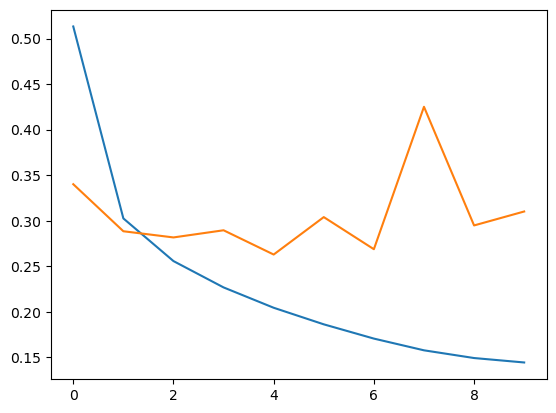

In [102]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

In [109]:
tr_scs=m.evaluate(e_tr_x,e_tr_y)
val_scs=m.evaluate(e_val_x,e_val_y)
tt_scs=m.evaluate(e_tt_x,e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9606 - loss: 0.1047
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9147 - loss: 0.3228
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9032 - loss: 0.3542


In [115]:
tr_scs

[0.13938800990581512, 0.9528958201408386]

In [117]:
all_acc=abs(tr_scs[1]-val_scs[1])+abs(tr_scs[1]-tt_scs[1])+abs(tt_scs[1]-val_scs[1])
all_acc

0.09659159183502197

In [119]:
all_loss=abs(tr_scs[0]-val_scs[0])+abs(tr_scs[0]-tt_scs[0])+abs(tt_scs[0]-val_scs[0])
all_loss

0.4127301871776581

In [113]:
np.abs([1,-2,3])

array([1, 2, 3])

In [57]:
m.predict(e_tr_x).shape

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


(48000, 10)

In [61]:
e_tr_y.shape

(48000, 10)

In [63]:
py=m.predict(e_tr_x)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


In [64]:
ty=e_tr_y

In [83]:
np.argmax(py,axis=1)

array([4, 1, 1, ..., 1, 4, 1], dtype=int64)

In [85]:
np.argmax(ty,axis=1)

array([5, 7, 4, ..., 3, 5, 2], dtype=int64)

In [89]:
print(classification_report(np.argmax(py,axis=1),np.argmax(ty,axis=1)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.71      0.11      0.19     30574
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00       265
           4       0.10      0.03      0.04     17111
           5       0.01      0.62      0.01        40
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         0

    accuracy                           0.08     48000
   macro avg       0.08      0.08      0.02     48000
weighted avg       0.49      0.08      0.14     48000



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
